In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import os
import pickle
import sympy as smp
import numpy as np
import matplotlib.pyplot as plt
import copy
from sympy import simplify, factor, cancel
from scipy.special import jv, kv, hankel1, iv
 
from continuum_mechanics import vector
from continuum_mechanics import solids
 
from wave_plotter import plot_scalar_field, enable_latex_style, plot_field_grid
from extra_fns import (latex_print, grad, lap_vec, rotation,
                       complete_strain_stress_ccst, classical_limit_system)

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SYMBOLIC SETUP
# ─────────────────────────────────────────────────────────────────────────────
r, th, z = smp.symbols('r, theta, z')
n        = smp.symbols('n', integer=True)
 
# exterior material
a, rho, mu, lam_lame, eta, ell = smp.symbols(
    'a, \\rho, \\mu, \\lambda, \\eta, \\ell', positive=True)
k, w0, omega, beta1, beta2 = smp.symbols(
    'k_S, w_0, \\omega, \\beta_1, \\beta_2', real=True)
 
# interior material  (primes)
mu_p, lam_lame_p, eta_p, ell_p = smp.symbols(
    "\\mu', \\lambda', \\eta', \\ell'", positive=True)
k_p, beta1_p, beta2_p = smp.symbols(
    "k_S', \\beta_1', \\beta_2' ", real=True)
 
# coefficients: An, Dn inside — Bn, Cn outside
An, Bn, Cn, Dn = smp.symbols('A_n, B_n, C_n, D_n')
 
vareps = smp.Function('\\varepsilon')(n)
i      = smp.I
 
# displacement functions
u_r  = smp.Function('u_r')(r, th, z)
u_th = smp.Function('u_{\\theta}')(r, th, z)
u_z  = smp.Function('u_z')(r, th, z)
 
# refracted field functions (inside)
u_r_f  = smp.Function("u_r^{(f)}")(r, th, z)
u_th_f = smp.Function("u_{\\theta}^{(f)}")(r, th, z)
u_z_f  = smp.Function("u_z^{(f)}")(r, th, z)
 
u   = smp.Matrix([u_r,   u_th,   u_z])
u_f = smp.Matrix([u_r_f, u_th_f, u_z_f])
cyl = (r, th, z)
h   = (1, r, 1)
 
display(u)
display(u_f)

Matrix([
[       u_r(r, theta, z)],
[u_{\theta}(r, theta, z)],
[       u_z(r, theta, z)]])

Matrix([
[       u_r^{(f)}(r, theta, z)],
[u_{\theta}^{(f)}(r, theta, z)],
[       u_z^{(f)}(r, theta, z)]])

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# KINEMATICS AND STRESSES
# exterior uses (mu, eta=mu*ell^2)
# interior uses (mu', eta'=mu'*ell'^2)
# ─────────────────────────────────────────────────────────────────────────────
e_ten,   curv_ten   = solids.disp_def_cst(u,   cyl, h)
e_ten_f, curv_ten_f = solids.disp_def_cst(u_f, cyl, h)
 
w_vec,   w_ten   = rotation(u,   cyl, h)
w_vec_f, w_ten_f = rotation(u_f, cyl, h)
 
sigma_ten,   *_, mu_ten   = complete_strain_stress_ccst(
    e_ten,   curv_ten,   w_ten,   cyl, h, (lam_lame,   mu,   eta))
sigma_ten_f, *_, mu_ten_f = complete_strain_stress_ccst(
    e_ten_f, curv_ten_f, w_ten_f, cyl, h, (lam_lame_p, mu_p, eta_p))
 
antiplane = {
    u_r:   0, u_th:   0, smp.diff(u_z,   z): 0,
    u_r_f: 0, u_th_f: 0, smp.diff(u_z_f, z): 0,
}
 
u_ap   = u.subs(antiplane)
u_f_ap = u_f.subs(antiplane)
 
sigma_ap   = simplify(sigma_ten.subs(antiplane).doit())
sigma_ap_f = simplify(sigma_ten_f.subs(antiplane).doit())
w_ap       = w_vec.subs(antiplane).doit()
w_ap_f     = w_vec_f.subs(antiplane).doit()
mu_ap      = mu_ten.subs(antiplane).doit()
mu_ap_f    = mu_ten_f.subs(antiplane).doit()

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# BOUNDARY CONDITIONS AND SOLUTION
#
# at r = a, 4 BCs (continuity):
#   BC1: u_z^{inc+scat} = u_z^{(f)}          (displacement)
#   BC2: omega_th^{inc+scat} = omega_th^{(f)} (rotation = 1/2 * du_z/dr)
#   BC3: sigma_rz^{inc+scat} = sigma_rz^{(f)} (force traction)
#   BC4: mu_r_theta^{inc+scat} = mu_r_theta^{(f)} (couple stress traction)
#
# unknowns: An (I_n inside), Bn (K_n outside), Cn (H_n outside), Dn (J_n inside)
# ─────────────────────────────────────────────────────────────────────────────
 
# incident + scattered field (exterior, r > a)
u_z_ext = (
    w0 * vareps * i**n * smp.besselj(n, k*r)
    + Bn * smp.besselk(n, beta1*r)
    + Cn * smp.hankel1(n, beta2*r)
) * smp.cos(n*th)
 
# refracted field (interior, r < a)
# I_n: modified Bessel of 1st kind (regular at r=0, evanescent)
# J_n: propagating wave inside
u_z_int = (
    An * smp.besseli(n, beta1_p*r)
    + Dn * smp.besselj(n, k_p*r)
) * smp.cos(n*th)
 
sln_ext = {smp.Function('u_z')(r, th, z):     u_z_ext}
sln_int = {smp.Function("u_z^{(f)}")(r, th, z): u_z_int}
 
display(u_z_ext)
display(u_z_int)
 
# BCs as symbolic equations
bdc_1 = smp.Eq(u_ap[2],       u_f_ap[2])
bdc_2 = smp.Eq(w_ap[1],       w_ap_f[1])
bdc_3 = smp.Eq(sigma_ap[0,2], sigma_ap_f[0,2])
bdc_4 = smp.Eq(mu_ap[0,1],    mu_ap_f[0,1])
 
display(bdc_1)
display(bdc_2)
display(bdc_3)
display(bdc_4)

(I**n*w_0*\varepsilon(n)*besselj(n, k_S*r) + B_n*besselk(n, \beta_1*r) + C_n*hankel1(n, \beta_2*r))*cos(n*theta)

(A_n*besseli(n, \beta_1'*r) + D_n*besselj(n, k_S'*r))*cos(n*theta)

Eq(u_z(r, theta, z), u_z^{(f)}(r, theta, z))

Eq(-Derivative(u_z(r, theta, z), r)/2, -Derivative(u_z^{(f)}(r, theta, z), r)/2)

Eq(\eta*Derivative(u_z(r, theta, z), (r, 3)) + \eta*Derivative(u_z(r, theta, z), (r, 2))/r + \eta*Derivative(u_z(r, theta, z), r, (theta, 2))/r**2 + \mu*Derivative(u_z(r, theta, z), r), \eta'*Derivative(u_z^{(f)}(r, theta, z), (r, 3)) + \eta'*Derivative(u_z^{(f)}(r, theta, z), (r, 2))/r + \eta'*Derivative(u_z^{(f)}(r, theta, z), r, (theta, 2))/r**2 + \mu'*Derivative(u_z^{(f)}(r, theta, z), r))

Eq(-2*\eta*(-r*Derivative(u_z(r, theta, z), (r, 2)) - Derivative(u_z(r, theta, z), r) - Derivative(u_z(r, theta, z), (theta, 2))/r)/r, -2*\eta'*(-r*Derivative(u_z^{(f)}(r, theta, z), (r, 2)) - Derivative(u_z^{(f)}(r, theta, z), r) - Derivative(u_z^{(f)}(r, theta, z), (theta, 2))/r)/r)

In [5]:
# substitute solutions and evaluate at r = a
def apply_bcs(bdc, r_val=a):
    return factor(
        bdc.subs(sln_ext).subs(sln_int).doit().subs({r: r_val})
    )
 
bdc_1_subs = apply_bcs(bdc_1)
bdc_2_subs = apply_bcs(bdc_2)
bdc_3_subs = apply_bcs(bdc_3)
bdc_4_subs = apply_bcs(bdc_4)
 
display(bdc_1_subs)
display(bdc_2_subs)
display(bdc_3_subs)
display(bdc_4_subs)

Eq((I**n*w_0*\varepsilon(n)*besselj(n, a*k_S) + B_n*besselk(n, \beta_1*a) + C_n*hankel1(n, \beta_2*a))*cos(n*theta), (A_n*besseli(n, \beta_1'*a) + D_n*besselj(n, a*k_S'))*cos(n*theta))

Eq((-I**n*k_S*w_0*\varepsilon(n)*besselj(n - 1, a*k_S) + I**n*k_S*w_0*\varepsilon(n)*besselj(n + 1, a*k_S) + B_n*\beta_1*besselk(n - 1, \beta_1*a) + B_n*\beta_1*besselk(n + 1, \beta_1*a) - C_n*\beta_2*hankel1(n - 1, \beta_2*a) + C_n*\beta_2*hankel1(n + 1, \beta_2*a))*cos(n*theta)/4, -(A_n*\beta_1'*besseli(n - 1, \beta_1'*a) + A_n*\beta_1'*besseli(n + 1, \beta_1'*a) + D_n*k_S'*besselj(n - 1, a*k_S') - D_n*k_S'*besselj(n + 1, a*k_S'))*cos(n*theta)/4)

Eq(-(-I**n*\eta*a**2*k_S**3*w_0*\varepsilon(n)*besselj(n - 3, a*k_S) + 3*I**n*\eta*a**2*k_S**3*w_0*\varepsilon(n)*besselj(n - 1, a*k_S) - 3*I**n*\eta*a**2*k_S**3*w_0*\varepsilon(n)*besselj(n + 1, a*k_S) + I**n*\eta*a**2*k_S**3*w_0*\varepsilon(n)*besselj(n + 3, a*k_S) + 4*I**n*\eta*a*k_S**2*w_0*\varepsilon(n)*besselj(n, a*k_S) - 2*I**n*\eta*a*k_S**2*w_0*\varepsilon(n)*besselj(n - 2, a*k_S) - 2*I**n*\eta*a*k_S**2*w_0*\varepsilon(n)*besselj(n + 2, a*k_S) + 4*I**n*\eta*k_S*n**2*w_0*\varepsilon(n)*besselj(n - 1, a*k_S) - 4*I**n*\eta*k_S*n**2*w_0*\varepsilon(n)*besselj(n + 1, a*k_S) - 4*I**n*\mu*a**2*k_S*w_0*\varepsilon(n)*besselj(n - 1, a*k_S) + 4*I**n*\mu*a**2*k_S*w_0*\varepsilon(n)*besselj(n + 1, a*k_S) + B_n*\beta_1**3*\eta*a**2*besselk(n - 3, \beta_1*a) + 3*B_n*\beta_1**3*\eta*a**2*besselk(n - 1, \beta_1*a) + 3*B_n*\beta_1**3*\eta*a**2*besselk(n + 1, \beta_1*a) + B_n*\beta_1**3*\eta*a**2*besselk(n + 3, \beta_1*a) - 4*B_n*\beta_1**2*\eta*a*besselk(n, \beta_1*a) - 2*B_n*\beta_1**2*\eta*a*

Eq(\eta*(-2*I**n*a**2*k_S**2*w_0*\varepsilon(n)*besselj(n, a*k_S) + I**n*a**2*k_S**2*w_0*\varepsilon(n)*besselj(n - 2, a*k_S) + I**n*a**2*k_S**2*w_0*\varepsilon(n)*besselj(n + 2, a*k_S) + 2*I**n*a*k_S*w_0*\varepsilon(n)*besselj(n - 1, a*k_S) - 2*I**n*a*k_S*w_0*\varepsilon(n)*besselj(n + 1, a*k_S) - 4*I**n*n**2*w_0*\varepsilon(n)*besselj(n, a*k_S) + 2*B_n*\beta_1**2*a**2*besselk(n, \beta_1*a) + B_n*\beta_1**2*a**2*besselk(n - 2, \beta_1*a) + B_n*\beta_1**2*a**2*besselk(n + 2, \beta_1*a) - 2*B_n*\beta_1*a*besselk(n - 1, \beta_1*a) - 2*B_n*\beta_1*a*besselk(n + 1, \beta_1*a) - 4*B_n*n**2*besselk(n, \beta_1*a) - 2*C_n*\beta_2**2*a**2*hankel1(n, \beta_2*a) + C_n*\beta_2**2*a**2*hankel1(n - 2, \beta_2*a) + C_n*\beta_2**2*a**2*hankel1(n + 2, \beta_2*a) + 2*C_n*\beta_2*a*hankel1(n - 1, \beta_2*a) - 2*C_n*\beta_2*a*hankel1(n + 1, \beta_2*a) - 4*C_n*n**2*hankel1(n, \beta_2*a))*cos(n*theta)/(2*a**2), \eta'*(2*A_n*\beta_1'**2*a**2*besseli(n, \beta_1'*a) + A_n*\beta_1'**2*a**2*besseli(n - 2, \beta_

In [6]:
# clean up: divide by cos(n*theta) and common factors
bdc_1_clean = smp.Eq(cancel(bdc_1_subs.lhs / smp.cos(n*th)),
                     cancel(bdc_1_subs.rhs / smp.cos(n*th)))
bdc_2_clean = smp.Eq(cancel(4*a * bdc_2_subs.lhs / smp.cos(n*th)),
                     cancel(4*a * bdc_2_subs.rhs / smp.cos(n*th)))
bdc_3_clean = smp.Eq(cancel(8*a**2 * bdc_3_subs.lhs / smp.cos(n*th)),
                     cancel(8*a**2 * bdc_3_subs.rhs / smp.cos(n*th)))
bdc_4_clean = smp.Eq(cancel(2*a**2 * bdc_4_subs.lhs / smp.cos(n*th)),
                     cancel(2*a**2 * bdc_4_subs.rhs / smp.cos(n*th)))
 
display(bdc_1_clean)
display(bdc_2_clean)
display(bdc_3_clean)
display(bdc_4_clean)

Eq(I**n*w_0*\varepsilon(n)*besselj(n, a*k_S) + B_n*besselk(n, \beta_1*a) + C_n*hankel1(n, \beta_2*a), A_n*besseli(n, \beta_1'*a) + D_n*besselj(n, a*k_S'))

Eq(-I**n*a*k_S*w_0*\varepsilon(n)*besselj(n - 1, a*k_S) + I**n*a*k_S*w_0*\varepsilon(n)*besselj(n + 1, a*k_S) + B_n*\beta_1*a*besselk(n - 1, \beta_1*a) + B_n*\beta_1*a*besselk(n + 1, \beta_1*a) - C_n*\beta_2*a*hankel1(n - 1, \beta_2*a) + C_n*\beta_2*a*hankel1(n + 1, \beta_2*a), -A_n*\beta_1'*a*besseli(n - 1, \beta_1'*a) - A_n*\beta_1'*a*besseli(n + 1, \beta_1'*a) - D_n*a*k_S'*besselj(n - 1, a*k_S') + D_n*a*k_S'*besselj(n + 1, a*k_S'))

Eq(I**n*\eta*a**2*k_S**3*w_0*\varepsilon(n)*besselj(n - 3, a*k_S) - 3*I**n*\eta*a**2*k_S**3*w_0*\varepsilon(n)*besselj(n - 1, a*k_S) + 3*I**n*\eta*a**2*k_S**3*w_0*\varepsilon(n)*besselj(n + 1, a*k_S) - I**n*\eta*a**2*k_S**3*w_0*\varepsilon(n)*besselj(n + 3, a*k_S) - 4*I**n*\eta*a*k_S**2*w_0*\varepsilon(n)*besselj(n, a*k_S) + 2*I**n*\eta*a*k_S**2*w_0*\varepsilon(n)*besselj(n - 2, a*k_S) + 2*I**n*\eta*a*k_S**2*w_0*\varepsilon(n)*besselj(n + 2, a*k_S) - 4*I**n*\eta*k_S*n**2*w_0*\varepsilon(n)*besselj(n - 1, a*k_S) + 4*I**n*\eta*k_S*n**2*w_0*\varepsilon(n)*besselj(n + 1, a*k_S) + 4*I**n*\mu*a**2*k_S*w_0*\varepsilon(n)*besselj(n - 1, a*k_S) - 4*I**n*\mu*a**2*k_S*w_0*\varepsilon(n)*besselj(n + 1, a*k_S) - B_n*\beta_1**3*\eta*a**2*besselk(n - 3, \beta_1*a) - 3*B_n*\beta_1**3*\eta*a**2*besselk(n - 1, \beta_1*a) - 3*B_n*\beta_1**3*\eta*a**2*besselk(n + 1, \beta_1*a) - B_n*\beta_1**3*\eta*a**2*besselk(n + 3, \beta_1*a) + 4*B_n*\beta_1**2*\eta*a*besselk(n, \beta_1*a) + 2*B_n*\beta_1**2*\eta*a*bes

Eq(-2*I**n*\eta*a**2*k_S**2*w_0*\varepsilon(n)*besselj(n, a*k_S) + I**n*\eta*a**2*k_S**2*w_0*\varepsilon(n)*besselj(n - 2, a*k_S) + I**n*\eta*a**2*k_S**2*w_0*\varepsilon(n)*besselj(n + 2, a*k_S) + 2*I**n*\eta*a*k_S*w_0*\varepsilon(n)*besselj(n - 1, a*k_S) - 2*I**n*\eta*a*k_S*w_0*\varepsilon(n)*besselj(n + 1, a*k_S) - 4*I**n*\eta*n**2*w_0*\varepsilon(n)*besselj(n, a*k_S) + 2*B_n*\beta_1**2*\eta*a**2*besselk(n, \beta_1*a) + B_n*\beta_1**2*\eta*a**2*besselk(n - 2, \beta_1*a) + B_n*\beta_1**2*\eta*a**2*besselk(n + 2, \beta_1*a) - 2*B_n*\beta_1*\eta*a*besselk(n - 1, \beta_1*a) - 2*B_n*\beta_1*\eta*a*besselk(n + 1, \beta_1*a) - 4*B_n*\eta*n**2*besselk(n, \beta_1*a) - 2*C_n*\beta_2**2*\eta*a**2*hankel1(n, \beta_2*a) + C_n*\beta_2**2*\eta*a**2*hankel1(n - 2, \beta_2*a) + C_n*\beta_2**2*\eta*a**2*hankel1(n + 2, \beta_2*a) + 2*C_n*\beta_2*\eta*a*hankel1(n - 1, \beta_2*a) - 2*C_n*\beta_2*\eta*a*hankel1(n + 1, \beta_2*a) - 4*C_n*\eta*n**2*hankel1(n, \beta_2*a), 2*A_n*\beta_1'**2*\eta'*a**2*besseli

In [7]:
# build 4x4 system A * [An, Bn, Cn, Dn]^T = b
A_mat, b_vec = smp.linear_eq_to_matrix(
    [bdc_1_clean, bdc_2_clean, bdc_3_clean, bdc_4_clean],
    [An, Bn, Cn, Dn]
)
 
display(simplify(A_mat))
latex_print(simplify(A_mat))

display(simplify(b_vec))
latex_print(simplify(b_vec))


Matrix([
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        -besseli(n, \beta_1'*a),                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

\left[\begin{matrix}- I_{n}\left(\beta_{1'} a\right) & K_{n}\left(\beta_{1} a\right) & H^{(1)}_{n}\left(\beta_{2} a\right) & - J_{n}\left(a k_{S'}\right)\\\beta_{1'} a \left(I_{n - 1}\left(\beta_{1'} a\right) + I_{n + 1}\left(\beta_{1'} a\right)\right) & \beta_{1} a \left(K_{n - 1}\left(\beta_{1} a\right) + K_{n + 1}\left(\beta_{1} a\right)\right) & \beta_{2} a \left(- H^{(1)}_{n - 1}\left(\beta_{2} a\right) + H^{(1)}_{n + 1}\left(\beta_{2} a\right)\right) & a k_{S'} \left(J_{n - 1}\left(a k_{S'}\right) - J_{n + 1}\left(a k_{S'}\right)\right)\\\beta_{1'} \left(- \beta_{1'}^{2} \eta' a^{2} I_{n - 3}\left(\beta_{1'} a\right) - 3 \beta_{1'}^{2} \eta' a^{2} I_{n - 1}\left(\beta_{1'} a\right) - 3 \beta_{1'}^{2} \eta' a^{2} I_{n + 1}\left(\beta_{1'} a\right) - \beta_{1'}^{2} \eta' a^{2} I_{n + 3}\left(\beta_{1'} a\right) - 4 \beta_{1'} \eta' a I_{n}\left(\beta_{1'} a\right) - 2 \beta_{1'} \eta' a I_{n - 2}\left(\beta_{1'} a\right) - 2 \beta_{1'} \eta' a I_{n + 2}\left(\beta_{1'} a\right) + 4

Matrix([
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

\left[\begin{matrix}- i^{n} w_{0} \varepsilon{\left(n \right)} J_{n}\left(a k_{S}\right)\\i^{n} a k_{S} w_{0} \left(J_{n - 1}\left(a k_{S}\right) - J_{n + 1}\left(a k_{S}\right)\right) \varepsilon{\left(n \right)}\\\frac{8 i^{n} w_{0} \left(\eta a^{5} k_{S}^{5} J_{n + 3}\left(a k_{S}\right) - 3 \eta a^{4} k_{S}^{4} n J_{n + 2}\left(a k_{S}\right) - 4 \eta a^{4} k_{S}^{4} J_{n + 2}\left(a k_{S}\right) - 2 \eta a^{3} k_{S}^{3} n^{2} J_{n + 3}\left(a k_{S}\right) - 2 \eta a^{3} k_{S}^{3} n J_{n + 3}\left(a k_{S}\right) - \eta a^{3} k_{S}^{3} J_{n + 3}\left(a k_{S}\right) + 4 \eta a^{2} k_{S}^{2} n^{3} J_{n + 2}\left(a k_{S}\right) + 10 \eta a^{2} k_{S}^{2} n^{2} J_{n + 2}\left(a k_{S}\right) + 11 \eta a^{2} k_{S}^{2} n J_{n + 2}\left(a k_{S}\right) + 4 \eta a^{2} k_{S}^{2} J_{n + 2}\left(a k_{S}\right) - 4 \eta a k_{S} n^{3} J_{n + 3}\left(a k_{S}\right) - 2 \eta a k_{S} n^{2} J_{n + 3}\left(a k_{S}\right) + 2 \eta a k_{S} n J_{n + 3}\left(a k_{S}\right) + 8 \eta n^{4} J_{n + 2}\left(a k_

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CLASSICAL LIMIT  (verification)
# ─────────────────────────────────────────────────────────────────────────────
A_cl, b_cl, sol_cl = classical_limit_system(
    A_mat, b_vec,
    beta1_list = [beta1,  beta1_p],
    beta2_list = [beta2,  beta2_p],
    kS_list    = [k,      k_p],
    eta_list   = [eta,    eta_p],
    var_names  = ["An", "Bn", "Cn", "Dn"]
)
 
# classical: Bn → 0, An → 0 (no evanescent waves)
# Cn → classical scattering coeff, Dn → classical refraction coeff
for name, expr in sol_cl.items():
    print(f"\n{name}_classical:")
    display(simplify(expr))

  Pass: zeroed ['An', 'Bn'], remaining: ['Cn', 'Dn']
Classical limit → zero : ['An', 'Bn']
Classical limit → live : ['Cn', 'Dn']
Classical limit → rows : [0, 1, 2]
  [numeric rank fallback] zero-size array to reduction operation maximum which has no identity
Classical limit → selected rows : [0, 1]

An_classical:


0


Bn_classical:


0


Cn_classical:


2*I**n*a*w_0*(k_S*besselj(n, a*k_S')*besselj(n + 1, a*k_S) - k_S'*besselj(n, a*k_S)*besselj(n + 1, a*k_S'))*\varepsilon(n)/(a*k_S*besselj(n, a*k_S')*hankel1(n - 1, a*k_S) - a*k_S*besselj(n, a*k_S')*hankel1(n + 1, a*k_S) + 2*a*k_S'*besselj(n + 1, a*k_S')*hankel1(n, a*k_S) - 2*n*besselj(n, a*k_S')*hankel1(n, a*k_S))


Dn_classical:


I**n*w_0*(a*k_S*besselj(n, a*k_S)*hankel1(n - 1, a*k_S) - a*k_S*besselj(n, a*k_S)*hankel1(n + 1, a*k_S) + 2*a*k_S*besselj(n + 1, a*k_S)*hankel1(n, a*k_S) - 2*n*besselj(n, a*k_S)*hankel1(n, a*k_S))*\varepsilon(n)/(a*k_S*besselj(n, a*k_S')*hankel1(n - 1, a*k_S) - a*k_S*besselj(n, a*k_S')*hankel1(n + 1, a*k_S) + 2*a*k_S'*besselj(n + 1, a*k_S')*hankel1(n, a*k_S) - 2*n*besselj(n, a*k_S')*hankel1(n, a*k_S))

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# ADIMENSIONALIZATION
# khat = k_S*a, lhat = ell/a, khat_p = k_S'*a, lhat_p = ell'/a
# mu_ratio = mu'/mu
# free symbols after adim: {n, khat, lhat, khat_p, lhat_p, mu_ratio}
# ─────────────────────────────────────────────────────────────────────────────
khat, lhat, khat_p, lhat_p, mu_ratio = smp.symbols(
    "\\hat{k}_S, \\hat{\\ell}, \\hat{k}_S', \\hat{\\ell}', \\mu'/\\mu",
    positive=True
)

# step 1: eta = mu*ell^2,  eta' = mu'*ell'^2
A_ad = A_mat.subs({eta: mu * ell**2, eta_p: mu_p * ell_p**2})
b_ad = b_vec.subs({eta: mu * ell**2, eta_p: mu_p * ell_p**2})

# step 2: beta definitions
A_ad = A_ad.subs({
    beta1:   smp.sqrt((1 + smp.sqrt(1 + 4*ell**2   * k**2))    / (2*ell**2)),
    beta2:   smp.sqrt(-(1 - smp.sqrt(1 + 4*ell**2   * k**2))   / (2*ell**2)),
    beta1_p: smp.sqrt((1 + smp.sqrt(1 + 4*ell_p**2  * k_p**2)) / (2*ell_p**2)),
    beta2_p: k_p,   # propagating wave inside uses k_p directly
})
b_ad = b_ad.subs({
    beta1:   smp.sqrt((1 + smp.sqrt(1 + 4*ell**2   * k**2))    / (2*ell**2)),
    beta2:   smp.sqrt(-(1 - smp.sqrt(1 + 4*ell**2   * k**2))   / (2*ell**2)),
    beta1_p: smp.sqrt((1 + smp.sqrt(1 + 4*ell_p**2  * k_p**2)) / (2*ell_p**2)),
    beta2_p: k_p,
})

# step 3: k=khat/a, ell=lhat*a, k_p=khat_p/a, ell_p=lhat_p*a, mu_p=mu_ratio*mu, w0=1
subs_dim = {k: khat/a, ell: lhat*a,
            k_p: khat_p/a, ell_p: lhat_p*a,
            mu_p: mu_ratio * mu, w0: 1}

A_ad = A_ad.subs(subs_dim)
b_ad = b_ad.subs(subs_dim)

# step 4: vareps
A_ad = A_ad.subs(vareps, smp.Piecewise((1, smp.Eq(n, 0)), (2, True)))
b_ad = b_ad.subs(vareps, smp.Piecewise((1, smp.Eq(n, 0)), (2, True)))

# step 5: divide stress rows (2,3) by mu — mu is a common factor there
#         rows 0,1 (displacement, rotation) have no mu
for col in range(4):
    A_ad[2, col] = cancel(A_ad[2, col] / mu)
    A_ad[3, col] = cancel(A_ad[3, col] / mu)
b_ad[2] = cancel(b_ad[2] / mu)
b_ad[3] = cancel(b_ad[3] / mu)

# step 6: set mu=1 (cancelled in stress rows, never appeared in kinematic rows)
#         set a=1 (cancels naturally in Bessel arguments)
A_ad = A_ad.subs({mu: 1, a: 1})
b_ad = b_ad.subs({mu: 1, a: 1})

print("Free symbols in A_ad:", A_ad.free_symbols)
# → {n, khat, lhat, khat_p, lhat_p, mu_ratio}
print("Free symbols in b_ad:", b_ad.free_symbols)
# → {n, khat, lhat}

Free symbols in A_ad: {\hat{\ell}, \hat{k}_S, n, \hat{\ell}', \hat{k}_S', \mu'/\mu}
Free symbols in b_ad: {n, \hat{\ell}, \hat{k}_S}



Computing SH elastic field:
  khat=2.0, lhat=0.1
  khat'=2.5, lhat'=0.1, mu'/mu=2.0
  Solving coefficients...


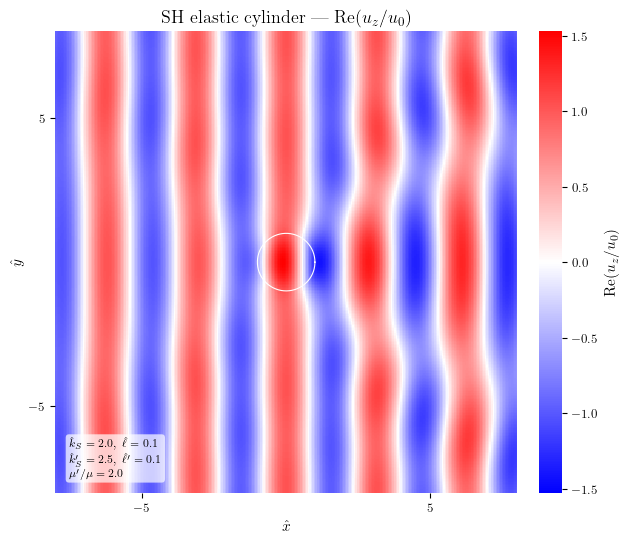

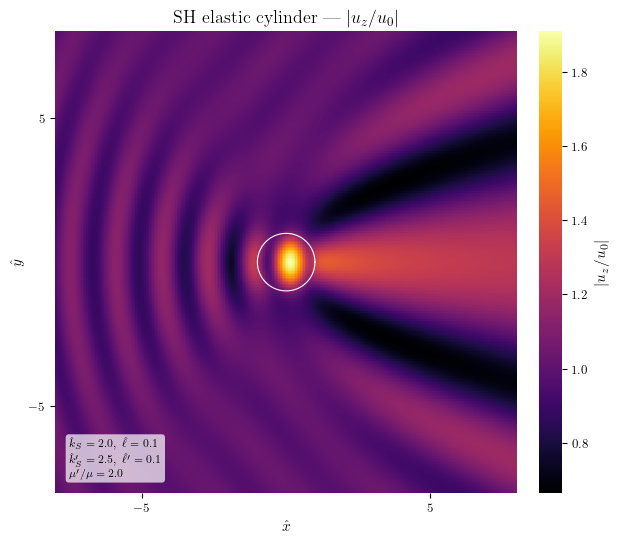

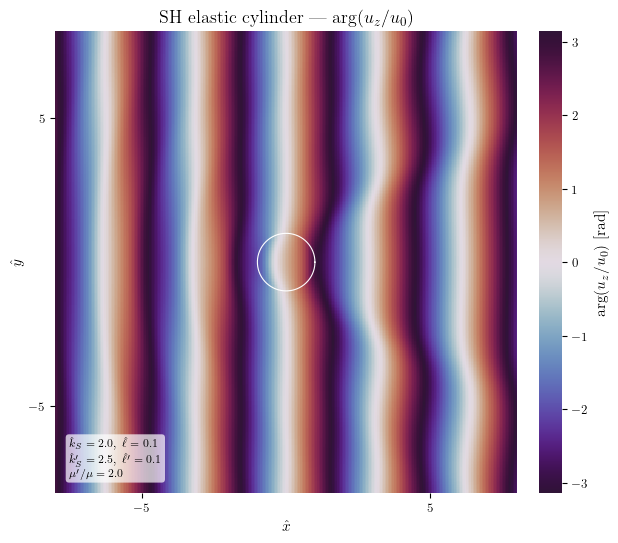

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# LAMBDIFY
# ─────────────────────────────────────────────────────────────────────────────
_bessel_mods = [{"besselj": jv, "besselk": kv, "hankel1": hankel1,
                 "besseli": iv}, "numpy"]

_sym_args = (n, khat, lhat, khat_p, lhat_p, mu_ratio)

A_func = smp.lambdify(_sym_args, A_ad.tolist(), modules=_bessel_mods)
b_func = smp.lambdify(_sym_args, b_ad.tolist(), modules=_bessel_mods)


# ─────────────────────────────────────────────────────────────────────────────
# COEFFICIENT SOLVER
# ─────────────────────────────────────────────────────────────────────────────
def solve_coefficients(khat_val, lhat_val, khat_p_val, lhat_p_val,
                       mu_ratio_val, Nmax):
    An_vals, Bn_vals, Cn_vals, Dn_vals = {}, {}, {}, {}
    for n_val in range(Nmax + 1):
        try:
            A_num = np.array(
                A_func(n_val, khat_val, lhat_val,
                       khat_p_val, lhat_p_val, mu_ratio_val),
                dtype=complex
            )
            b_num = np.array(
                b_func(n_val, khat_val, lhat_val,
                       khat_p_val, lhat_p_val, mu_ratio_val),
                dtype=complex
            ).flatten()
            sol = np.linalg.solve(A_num, b_num)
            An_vals[n_val] = sol[0]
            Bn_vals[n_val] = sol[1]
            Cn_vals[n_val] = sol[2]
            Dn_vals[n_val] = sol[3]
        except np.linalg.LinAlgError:
            print(f"  [singular] n={n_val}")
            An_vals[n_val] = Bn_vals[n_val] = 0.0
            Cn_vals[n_val] = Dn_vals[n_val] = 0.0
    return An_vals, Bn_vals, Cn_vals, Dn_vals


# ─────────────────────────────────────────────────────────────────────────────
# FIELD FUNCTION
# ─────────────────────────────────────────────────────────────────────────────
def w_field_elastic(R_hat, TH, khat_val, lhat_val, khat_p_val, lhat_p_val,
                    mu_ratio_val, Nmax):
    """
    Total SH field for an elastic cylinder.
    Exterior (r >= 1): incident + scattered  [J_n, K_n, H_n]
    Interior (r <  1): refracted             [I_n, J_n]
    nan_to_num on full term — same strategy as SH_rigid/cavity.
    """
    b1  = np.sqrt((1 + np.sqrt(1 + 4*lhat_val**2   * khat_val**2))   / (2*lhat_val**2))
    b2  = np.sqrt(-(1 - np.sqrt(1 + 4*lhat_val**2   * khat_val**2))  / (2*lhat_val**2))
    b1p = np.sqrt((1 + np.sqrt(1 + 4*lhat_p_val**2  * khat_p_val**2)) / (2*lhat_p_val**2))

    print(f"  Solving coefficients...")
    An_vals, Bn_vals, Cn_vals, Dn_vals = solve_coefficients(
        khat_val, lhat_val, khat_p_val, lhat_p_val, mu_ratio_val, Nmax
    )

    mask_int = R_hat < 1.0
    mask_ext = ~mask_int
    W        = np.zeros_like(R_hat, dtype=complex)
    eps_n    = lambda nv: 1 if nv == 0 else 2

    # exterior
    R_e, TH_e = R_hat[mask_ext], TH[mask_ext]
    W_e = np.zeros_like(R_e, dtype=complex)
    for n_val in range(Nmax + 1):
        term = (
            eps_n(n_val) * (1j)**n_val * jv(n_val, khat_val * R_e)
            + Bn_vals[n_val] * kv(n_val, b1 * R_e)
            + Cn_vals[n_val] * hankel1(n_val, b2 * R_e)
        ) * np.cos(n_val * TH_e)
        cleaned = np.nan_to_num(term, nan=0.0, posinf=0.0, neginf=0.0)
        if np.any(~np.isfinite(term)):
            print(f"  [nan_to_num ext] n={n_val}")
        W_e += cleaned
    W[mask_ext] = W_e

    # interior
    R_i, TH_i = R_hat[mask_int], TH[mask_int]
    W_i = np.zeros_like(R_i, dtype=complex)
    for n_val in range(Nmax + 1):
        term = (
            An_vals[n_val] * iv(n_val, b1p * R_i)
            + Dn_vals[n_val] * jv(n_val, khat_p_val * R_i)
        ) * np.cos(n_val * TH_i)
        cleaned = np.nan_to_num(term, nan=0.0, posinf=0.0, neginf=0.0)
        if np.any(~np.isfinite(term)):
            print(f"  [nan_to_num int] n={n_val}")
        W_i += cleaned
    W[mask_int] = W_i

    return W


# ─────────────────────────────────────────────────────────────────────────────
# PARAMETERS AND MESH
# ─────────────────────────────────────────────────────────────────────────────
khat_val     = 2.0    # k_S * a  (exterior)
lhat_val     = 0.1    # ell / a  (exterior)
khat_p_val   = 2.5    # k_S'* a  (interior — slightly shorter wavelength)
lhat_p_val   = 0.1    # ell'/ a  (interior)
mu_ratio_val = 2.0    # mu'/mu   (stiffer cylinder)
Nmax         = 100

resolution = 300
L          = 8.0

x = np.linspace(-L, L, resolution)
y = np.linspace(-L, L, resolution)
X, Y   = np.meshgrid(x, y)
R_hat  = np.sqrt(X**2 + Y**2)
TH     = np.arctan2(Y, X)

print(f"\nComputing SH elastic field:")
print(f"  khat={khat_val}, lhat={lhat_val}")
print(f"  khat'={khat_p_val}, lhat'={lhat_p_val}, mu'/mu={mu_ratio_val}")

W       = w_field_elastic(R_hat, TH, khat_val, lhat_val,
                          khat_p_val, lhat_p_val, mu_ratio_val, Nmax)
W_real  = np.real(W)
W_mag   = np.abs(W)
W_phase = np.angle(W)


# ─────────────────────────────────────────────────────────────────────────────
# PLOT — individual figures
# white circle at r̂=1 marks boundary so continuity is visible
# ─────────────────────────────────────────────────────────────────────────────
import copy
enable_latex_style()

_param_str = (
    rf"$\hat{{k}}_S={khat_val},\ \hat{{\ell}}={lhat_val}$"        "\n"
    rf"$\hat{{k}}_S'={khat_p_val},\ \hat{{\ell}}'={lhat_p_val}$"  "\n"
    rf"$\mu'/\mu={mu_ratio_val}$"
)

# real part
plot_scalar_field(
    X, Y, W_real,
    cmap="bwr",
    cbar_label=r"$\mathrm{Re}(u_z/u_0)$",
    title=r"SH elastic cylinder — $\mathrm{Re}(u_z/u_0)$",
    xlabel=r"$\hat{x}$", ylabel=r"$\hat{y}$",
    center_zero=True, symmetric_limits=True,
    cylinder_radius=1.0,
    param_text=_param_str,
    filename="SH_E_real", save_folder="figs"
)

# magnitude
inferno_black = copy.copy(plt.cm.inferno)
inferno_black.set_bad("black")

plot_scalar_field(
    X, Y, W_mag,
    cmap="inferno",
    cbar_label=r"$|u_z/u_0|$",
    title=r"SH elastic cylinder — $|u_z/u_0|$",
    xlabel=r"$\hat{x}$", ylabel=r"$\hat{y}$",
    cylinder_radius=1.0,
    param_text=_param_str,
    filename="SH_E_mag", save_folder="figs"
)

# phase
plot_scalar_field(
    X, Y, W_phase,
    cmap="twilight_shifted",
    cbar_label=r"$\arg(u_z/u_0)$ [rad]",
    title=r"SH elastic cylinder — $\arg(u_z/u_0)$",
    xlabel=r"$\hat{x}$", ylabel=r"$\hat{y}$",
    vmin=-np.pi, vmax=np.pi,
    cylinder_radius=1.0,
    param_text=_param_str,
    filename="SH_E_phase", save_folder="figs"
)

khat = 5.0000
lhat = 0.500000
khat'= 10.0000
lhat'= 0.100000
mu'/mu = 2

Computing SH elastic field (old params)...
  Solving coefficients...


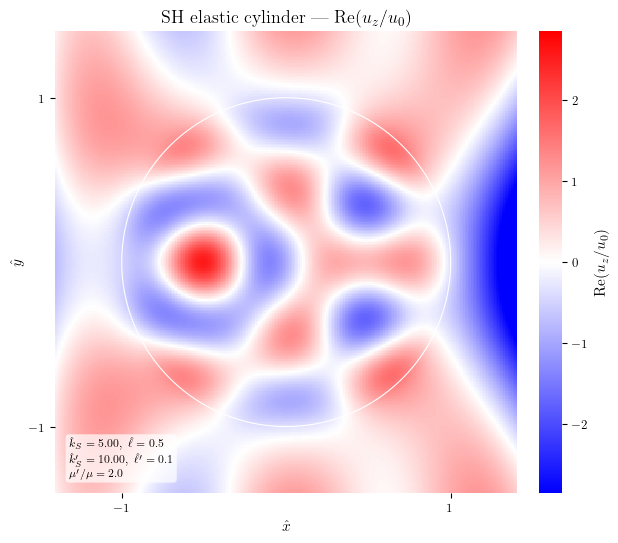

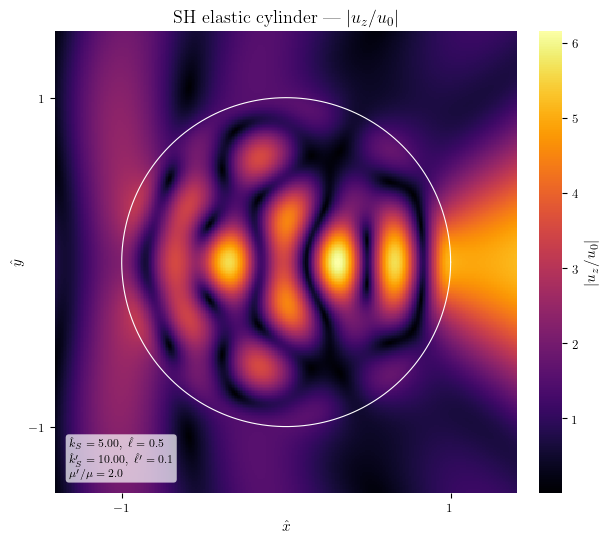

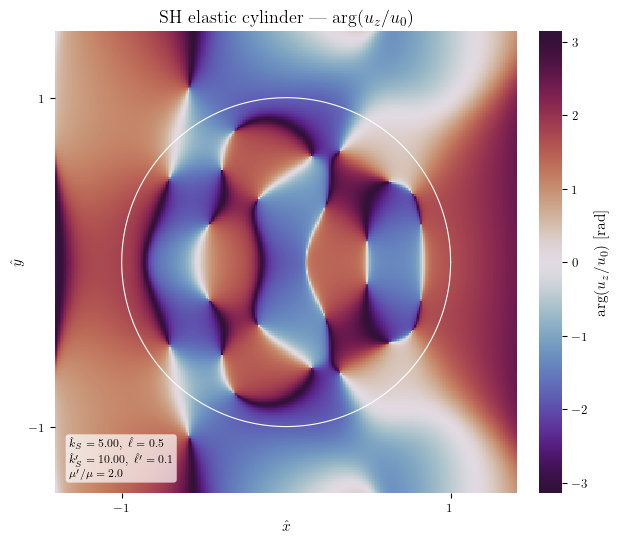

In [21]:
# dimensional params → dimensionless
# khat  = k_S  * a = (2π/lam_s)  * a = 2π * 1e-3 / 5e-4 = 4π ≈ 12.57
# lhat  = ell  / a = 5e-6 / 1e-3                         = 0.005
# khat' = k_S' * a = (2π/lam_s') * a = 2π * 1e-3 / 4e-4 = 5π ≈ 15.71
# lhat' = ell' / a = 5e-6 / 1e-3                         = 0.005
# mu_ratio = mu'/mu = 60e9/30e9                           = 2.0

khat_val_2     = 5
lhat_val_2     = 0.5             # = 0.005
khat_p_val_2   = 10
lhat_p_val_2   = 0.1               # = 0.5
mu_ratio_val_2 = 2
Nmax_2         = 100

print(f"khat = {khat_val_2:.4f}")
print(f"lhat = {lhat_val_2:.6f}")
print(f"khat'= {khat_p_val_2:.4f}")
print(f"lhat'= {lhat_p_val_2:.6f}")
print(f"mu'/mu = {mu_ratio_val_2}")\

_param_str_2 = (
    rf"$\hat{{k}}_S={khat_val_2:.2f},\ \hat{{\ell}}={lhat_val_2}$"       "\n"
    rf"$\hat{{k}}_S'={khat_p_val_2:.2f},\ \hat{{\ell}}'={lhat_p_val_2}$" "\n"
    rf"$\mu'/\mu={mu_ratio_val_2:.1f}$"
)

# mesh for old params — zoom in to [-2, 2] (in units of a)
L_2        = 1.4
resolution = 300

x2 = np.linspace(-L_2, L_2, resolution)
y2 = np.linspace(-L_2, L_2, resolution)
X2, Y2  = np.meshgrid(x2, y2)
R_hat2  = np.sqrt(X2**2 + Y2**2)
TH2     = np.arctan2(Y2, X2)

print(f"\nComputing SH elastic field (old params)...")
W2       = w_field_elastic(R_hat2, TH2, khat_val_2, lhat_val_2,
                            khat_p_val_2, lhat_p_val_2, mu_ratio_val_2, Nmax_2)
W2_real  = np.real(W2)
W2_mag   = np.abs(W2)
W2_phase = np.angle(W2)

enable_latex_style()

plot_scalar_field(
    X2, Y2, W2_real,
    cmap="bwr",
    cbar_label=r"$\mathrm{Re}(u_z/u_0)$",
    title=r"SH elastic cylinder — $\mathrm{Re}(u_z/u_0)$",
    xlabel=r"$\hat{x}$", ylabel=r"$\hat{y}$",
    center_zero=True, symmetric_limits=True,
    cylinder_radius=1.0,
    param_text=_param_str_2,
    vmax_percentile=99,
    filename="SH_E_real_2", save_folder="figs"
)

plot_scalar_field(
    X2, Y2, W2_mag,
    cmap="inferno",
    cbar_label=r"$|u_z/u_0|$",
    title=r"SH elastic cylinder — $|u_z/u_0|$",
    xlabel=r"$\hat{x}$", ylabel=r"$\hat{y}$",
    cylinder_radius=1.0,
    param_text=_param_str_2,
    filename="SH_E_mag_2", save_folder="figs"
)

plot_scalar_field(
    X2, Y2, W2_phase,
    cmap="twilight_shifted",
    cbar_label=r"$\arg(u_z/u_0)$ [rad]",
    title=r"SH elastic cylinder — $\arg(u_z/u_0)$",
    xlabel=r"$\hat{x}$", ylabel=r"$\hat{y}$",
    vmin=-np.pi, vmax=np.pi,
    cylinder_radius=1.0,
    param_text=_param_str_2,
    filename="SH_E_phase_2", save_folder="figs"
)

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# SH ELASTIC CYLINDER — BOUNDARY STRESSES AND DSCF
# ─────────────────────────────────────────────────────────────────────────────

import os
os.makedirs("figs", exist_ok=True)
os.makedirs("cache", exist_ok=True)

# Diagnostic: check nonzero antiplane stress components
print("Nonzero exterior sigma_ap components:")
for ii in range(3):
    for jj in range(3):
        if sigma_ap[ii, jj] != smp.S.Zero:
            print(f"  sigma_ap[{ii},{jj}] =")
            display(sigma_ap[ii, jj])

print("Nonzero interior sigma_ap_f components:")
for ii in range(3):
    for jj in range(3):
        if sigma_ap_f[ii, jj] != smp.S.Zero:
            print(f"  sigma_ap_f[{ii},{jj}] =")
            display(sigma_ap_f[ii, jj])

Nonzero exterior sigma_ap components:
  sigma_ap[0,2] =


\eta*Derivative(u_z(r, theta, z), (r, 3)) + \eta*Derivative(u_z(r, theta, z), (r, 2))/r + \eta*Derivative(u_z(r, theta, z), r, (theta, 2))/r**2 + \mu*Derivative(u_z(r, theta, z), r)

  sigma_ap[1,2] =


(\eta*(r**2*Derivative(u_z(r, theta, z), (r, 2), theta) - r*Derivative(u_z(r, theta, z), r, theta) + Derivative(u_z(r, theta, z), theta) + Derivative(u_z(r, theta, z), (theta, 3))) + \mu*r**2*Derivative(u_z(r, theta, z), theta))/r**3

  sigma_ap[2,0] =


...

(\eta'*(r**2*Derivative(u_z^{(f)}(r, theta, z), (r, 2), theta) - r*Derivative(u_z^{(f)}(r, theta, z), r, theta) + Derivative(u_z^{(f)}(r, theta, z), theta) + Derivative(u_z^{(f)}(r, theta, z), (theta, 3))) + \mu'*r**2*Derivative(u_z^{(f)}(r, theta, z), theta))/r**3

  sigma_ap_f[2,0] =


-\eta'*Derivative(u_z^{(f)}(r, theta, z), (r, 3)) - \eta'*Derivative(u_z^{(f)}(r, theta, z), (r, 2))/r - \eta'*Derivative(u_z^{(f)}(r, theta, z), r, (theta, 2))/r**2 + \mu'*Derivative(u_z^{(f)}(r, theta, z), r)

  sigma_ap_f[2,1] =


(-\eta'*(r**2*Derivative(u_z^{(f)}(r, theta, z), (r, 2), theta) - r*Derivative(u_z^{(f)}(r, theta, z), r, theta) + Derivative(u_z^{(f)}(r, theta, z), theta) + Derivative(u_z^{(f)}(r, theta, z), (theta, 3))) + \mu'*r**2*Derivative(u_z^{(f)}(r, theta, z), theta))/r**3

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# BOUNDARY FUNCTION BUILDER
# ─────────────────────────────────────────────────────────────────────────────

def _adim_boundary_expr(expr, side="ext"):
    """
    Builds a nondimensional boundary expression at r=a.
    
    side = "ext": uses exterior solution u_z_ext and exterior material.
    side = "int": uses interior solution u_z_int and interior material.
    """

    if side == "ext":
        expr_b = expr.subs(sln_ext).doit()
    elif side == "int":
        expr_b = expr.subs(sln_int).doit()
    else:
        raise ValueError("side must be 'ext' or 'int'.")

    expr_b = expr_b.subs({r: a})

    # C-CST constitutive substitutions
    expr_b = expr_b.subs({
        eta: mu * ell**2,
        eta_p: mu_p * ell_p**2,
    })

    # Beta substitutions
    expr_b = expr_b.subs({
        beta1: smp.sqrt((1 + smp.sqrt(1 + 4*ell**2*k**2)) / (2*ell**2)),
        beta2: smp.sqrt(-(1 - smp.sqrt(1 + 4*ell**2*k**2)) / (2*ell**2)),
        beta1_p: smp.sqrt((1 + smp.sqrt(1 + 4*ell_p**2*k_p**2)) / (2*ell_p**2)),
        beta2_p: k_p,
    })

    # Nondimensional variables
    expr_b = expr_b.subs({
        k: khat/a,
        ell: lhat*a,
        k_p: khat_p/a,
        ell_p: lhat_p*a,
        mu_p: mu_ratio * mu,
        w0: 1,
    })

    expr_b = expr_b.subs(vareps, smp.Piecewise((1, smp.Eq(n, 0)), (2, True)))

    # Set reference scale
    expr_b = expr_b.subs({mu: 1, a: 1})

    return simplify(expr_b)


def make_boundary_func(expr, name, side="ext"):
    """
    Lambdifies a boundary quantity at r=a.
    Keeps An, Bn, Cn, Dn as numerical arguments.
    No pickle cache, because lambdified functions are not reliably picklable.
    """

    print(f"Building boundary function: {name}, side={side}")

    expr_ad = _adim_boundary_expr(expr, side=side)

    func = smp.lambdify(
        (n, th, khat, lhat, khat_p, lhat_p, mu_ratio, An, Bn, Cn, Dn),
        expr_ad,
        modules=_bessel_mods
    )

    return func

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# RELEVANT BOUNDARY QUANTITIES
# ─────────────────────────────────────────────────────────────────────────────

# Exterior stresses
sig_rz_ext_func = make_boundary_func(sigma_ap[0, 2], "sigma_rz", side="ext")
sig_tz_ext_func = make_boundary_func(sigma_ap[1, 2], "sigma_thetaz", side="ext")

# Interior stresses
sig_rz_int_func = make_boundary_func(sigma_ap_f[0, 2], "sigma_rz", side="int")
sig_tz_int_func = make_boundary_func(sigma_ap_f[1, 2], "sigma_thetaz", side="int")

# Couple stress for BC verification
mu_rtheta_ext_func = make_boundary_func(mu_ap[0, 1], "mu_rtheta", side="ext")
mu_rtheta_int_func = make_boundary_func(mu_ap_f[0, 1], "mu_rtheta", side="int")

# Displacement and rotation for BC verification
uz_ext_func = make_boundary_func(u_ap[2], "uz", side="ext")
uz_int_func = make_boundary_func(u_f_ap[2], "uz", side="int")

omega_th_ext_func = make_boundary_func(w_ap[1], "omega_theta", side="ext")
omega_th_int_func = make_boundary_func(w_ap_f[1], "omega_theta", side="int")

Building boundary function: sigma_rz, side=ext
Building boundary function: sigma_thetaz, side=ext
Building boundary function: sigma_rz, side=int
Building boundary function: sigma_thetaz, side=int
Building boundary function: mu_rtheta, side=ext
Building boundary function: mu_rtheta, side=int
Building boundary function: uz, side=ext
Building boundary function: uz, side=int
Building boundary function: omega_theta, side=ext
Building boundary function: omega_theta, side=int


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# SERIES EVALUATION AT BOUNDARY
# ─────────────────────────────────────────────────────────────────────────────

def boundary_series(func, theta, khat_val, lhat_val, khat_p_val, lhat_p_val,
                    mu_ratio_val, Nmax=200):
    """
    Evaluates a boundary quantity at r=a by summing over n.
    """

    An_vals, Bn_vals, Cn_vals, Dn_vals = solve_coefficients(
        khat_val, lhat_val, khat_p_val, lhat_p_val, mu_ratio_val, Nmax
    )

    total = np.zeros_like(theta, dtype=complex)

    for n_val in range(Nmax + 1):
        term = func(
            n_val, theta,
            khat_val, lhat_val, khat_p_val, lhat_p_val, mu_ratio_val,
            An_vals[n_val], Bn_vals[n_val], Cn_vals[n_val], Dn_vals[n_val]
        )

        term = np.nan_to_num(term, nan=0.0, posinf=0.0, neginf=0.0)
        total += term

    return total

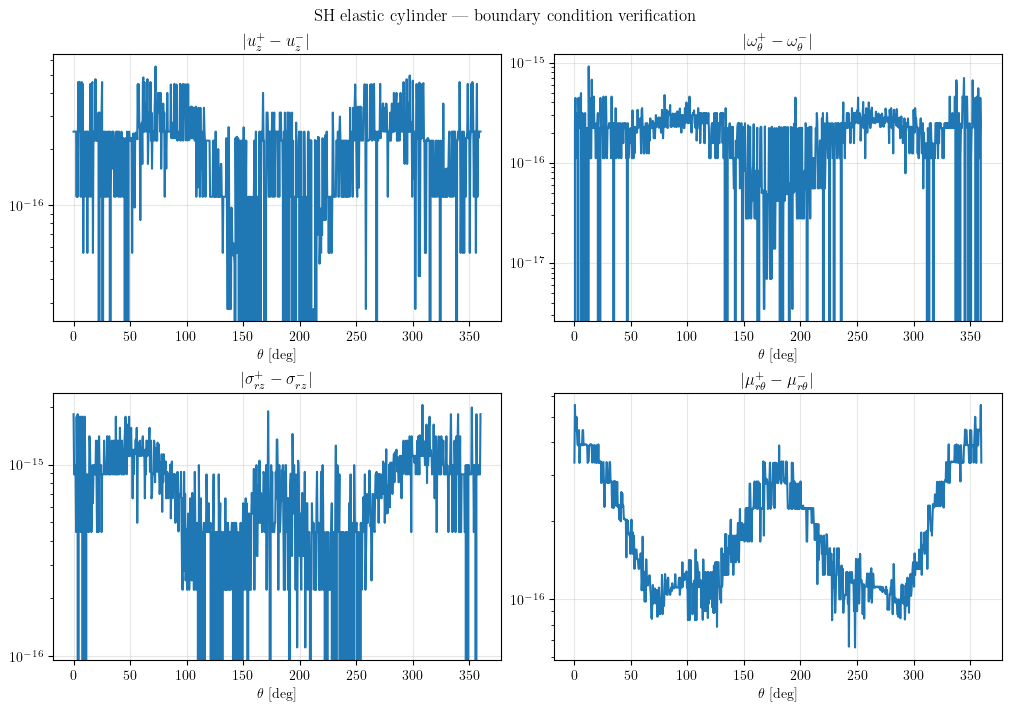

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 0 — BOUNDARY CONDITION VERIFICATION
# ─────────────────────────────────────────────────────────────────────────────

enable_latex_style()

theta = np.linspace(0, 2*np.pi, 800)

khat_val     = 2.0
lhat_val     = 0.1
khat_p_val   = 2.5
lhat_p_val   = 0.1
mu_ratio_val = 2.0
Nmax_bnd     = 200

uz_ext = boundary_series(uz_ext_func, theta, khat_val, lhat_val,
                         khat_p_val, lhat_p_val, mu_ratio_val, Nmax_bnd)
uz_int = boundary_series(uz_int_func, theta, khat_val, lhat_val,
                         khat_p_val, lhat_p_val, mu_ratio_val, Nmax_bnd)

om_ext = boundary_series(omega_th_ext_func, theta, khat_val, lhat_val,
                         khat_p_val, lhat_p_val, mu_ratio_val, Nmax_bnd)
om_int = boundary_series(omega_th_int_func, theta, khat_val, lhat_val,
                         khat_p_val, lhat_p_val, mu_ratio_val, Nmax_bnd)

srz_ext = boundary_series(sig_rz_ext_func, theta, khat_val, lhat_val,
                          khat_p_val, lhat_p_val, mu_ratio_val, Nmax_bnd)
srz_int = boundary_series(sig_rz_int_func, theta, khat_val, lhat_val,
                          khat_p_val, lhat_p_val, mu_ratio_val, Nmax_bnd)

mrt_ext = boundary_series(mu_rtheta_ext_func, theta, khat_val, lhat_val,
                          khat_p_val, lhat_p_val, mu_ratio_val, Nmax_bnd)
mrt_int = boundary_series(mu_rtheta_int_func, theta, khat_val, lhat_val,
                          khat_p_val, lhat_p_val, mu_ratio_val, Nmax_bnd)

fig, axs = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)

axs[0, 0].semilogy(np.rad2deg(theta), np.abs(uz_ext - uz_int))
axs[0, 0].set_title(r"$|u_z^+ - u_z^-|$")

axs[0, 1].semilogy(np.rad2deg(theta), np.abs(om_ext - om_int))
axs[0, 1].set_title(r"$|\omega_\theta^+ - \omega_\theta^-|$")

axs[1, 0].semilogy(np.rad2deg(theta), np.abs(srz_ext - srz_int))
axs[1, 0].set_title(r"$|\sigma_{rz}^+ - \sigma_{rz}^-|$")

axs[1, 1].semilogy(np.rad2deg(theta), np.abs(mrt_ext - mrt_int))
axs[1, 1].set_title(r"$|\mu_{r\theta}^+ - \mu_{r\theta}^-|$")

for ax in axs.flat:
    ax.set_xlabel(r"$\theta$ [deg]")
    ax.grid(True, alpha=0.3)

fig.suptitle("SH elastic cylinder — boundary condition verification")
plt.savefig("figs/SH_E_BC_verification.png", dpi=300)
plt.show()

  [singular] n=180
  [singular] n=180
  [singular] n=180
  [singular] n=180


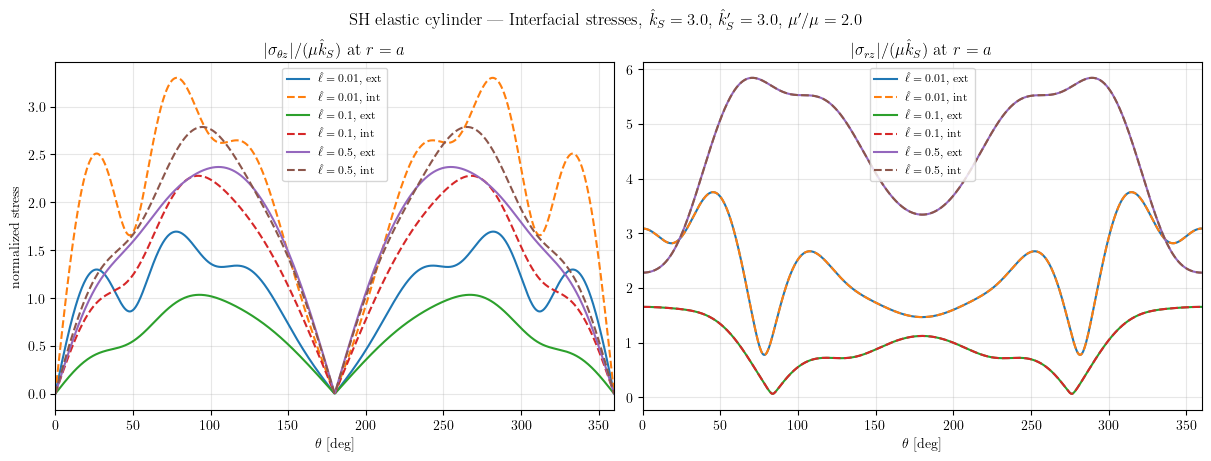

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1 — STRESSES AT THE INTERFACE
# Comparable with Shodja Fig. 7(a)(b), with ld=0
# ─────────────────────────────────────────────────────────────────────────────

theta = np.linspace(0, 2*np.pi, 800)
theta_deg = np.rad2deg(theta)

khat_val     = 3.0
khat_p_val   = 3.0
lhat_p_val   = 0.1
mu_ratio_val = 2.0
Nmax_bnd     = 200

lhat_vals = [0.01, 0.1, 0.5]

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

for lhat_val in lhat_vals:

    sig_tz_ext = boundary_series(sig_tz_ext_func, theta, khat_val, lhat_val,
                                 khat_p_val, lhat_p_val, mu_ratio_val, Nmax_bnd)
    sig_tz_int = boundary_series(sig_tz_int_func, theta, khat_val, lhat_val,
                                 khat_p_val, lhat_p_val, mu_ratio_val, Nmax_bnd)

    sig_rz_ext = boundary_series(sig_rz_ext_func, theta, khat_val, lhat_val,
                                 khat_p_val, lhat_p_val, mu_ratio_val, Nmax_bnd)
    sig_rz_int = boundary_series(sig_rz_int_func, theta, khat_val, lhat_val,
                                 khat_p_val, lhat_p_val, mu_ratio_val, Nmax_bnd)

    # Normalization by mu*khat_S. Since mu=1, divide by khat_val.
    axs[0].plot(theta_deg, np.abs(sig_tz_ext)/khat_val,
                label=rf"$\hat{{\ell}}={lhat_val}$, ext")
    axs[0].plot(theta_deg, np.abs(sig_tz_int)/khat_val,
                "--", label=rf"$\hat{{\ell}}={lhat_val}$, int")

    axs[1].plot(theta_deg, np.abs(sig_rz_ext)/khat_val,
                label=rf"$\hat{{\ell}}={lhat_val}$, ext")
    axs[1].plot(theta_deg, np.abs(sig_rz_int)/khat_val,
                "--", label=rf"$\hat{{\ell}}={lhat_val}$, int")

axs[0].set_title(r"$|\sigma_{\theta z}|/(\mu \hat{k}_S)$ at $r=a$")
axs[1].set_title(r"$|\sigma_{rz}|/(\mu \hat{k}_S)$ at $r=a$")

for ax in axs:
    ax.set_xlabel(r"$\theta$ [deg]")
    ax.set_xlim(0, 360)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncols=1)

axs[0].set_ylabel("normalized stress")

fig.suptitle(
    rf"SH elastic cylinder — Interfacial stresses, "
    rf"$\hat{{k}}_S={khat_val}$, $\hat{{k}}_S'={khat_p_val}$, $\mu'/\mu={mu_ratio_val}$"
)

plt.savefig("figs/SH_E_boundary_stresses.png", dpi=300)
plt.show()

  [singular] n=0
  [singular] n=1
  [singular] n=2
  [singular] n=3
  [singular] n=4
  [singular] n=5
  [singular] n=6
  [singular] n=7
  [singular] n=8
  [singular] n=9
  [singular] n=10
  [singular] n=11
  [singular] n=12
  [singular] n=13
  [singular] n=14
  [singular] n=15
  [singular] n=16
  [singular] n=17
  [singular] n=18
  [singular] n=19
  [singular] n=20
  [singular] n=21
  [singular] n=22
  [singular] n=23
  [singular] n=24
  [singular] n=25
  [singular] n=26
  [singular] n=27
  [singular] n=28
  [singular] n=29
  [singular] n=30
  [singular] n=31
  [singular] n=32
  [singular] n=33
  [singular] n=34
  [singular] n=35
  [singular] n=36
  [singular] n=37
  [singular] n=38
  [singular] n=39
  [singular] n=40
  [singular] n=41
  [singular] n=42
  [singular] n=43
  [singular] n=44
  [singular] n=45
  [singular] n=46
  [singular] n=47
  [singular] n=48
  [singular] n=49
  [singular] n=50
  [singular] n=51
  [singular] n=52
  [singular] n=53
  [singular] n=54
  [singular] n=55
  

<lambdifygenerated-1>:2: RuntimeWarning: overflow encountered in scalar multiply
  return [[-besseli(n, (1/2)*sqrt(2)*sqrt(sqrt(4*_Dummy_1030**2*_Dummy_1042**2 + 1) + 1)/_Dummy_1042), besselk(n, (1/2)*sqrt(2)*sqrt(sqrt(4*_Dummy_1041**2*_Dummy_1069**2 + 1) + 1)/_Dummy_1069), hankel1(n, (1/2)*sqrt(2)*sqrt(sqrt(4*_Dummy_1041**2*_Dummy_1069**2 + 1) - 1)/_Dummy_1069), -besselj(n, _Dummy_1030)], [(1/2)*sqrt(2)*sqrt(sqrt(4*_Dummy_1030**2*_Dummy_1042**2 + 1) + 1)*besseli(n - 1, (1/2)*sqrt(2)*sqrt(sqrt(4*_Dummy_1030**2*_Dummy_1042**2 + 1) + 1)/_Dummy_1042)/_Dummy_1042 + (1/2)*sqrt(2)*sqrt(sqrt(4*_Dummy_1030**2*_Dummy_1042**2 + 1) + 1)*besseli(n + 1, (1/2)*sqrt(2)*sqrt(sqrt(4*_Dummy_1030**2*_Dummy_1042**2 + 1) + 1)/_Dummy_1042)/_Dummy_1042, (1/2)*sqrt(2)*sqrt(sqrt(4*_Dummy_1041**2*_Dummy_1069**2 + 1) + 1)*besselk(n - 1, (1/2)*sqrt(2)*sqrt(sqrt(4*_Dummy_1041**2*_Dummy_1069**2 + 1) + 1)/_Dummy_1069)/_Dummy_1069 + (1/2)*sqrt(2)*sqrt(sqrt(4*_Dummy_1041**2*_Dummy_1069**2 + 1) + 1)*besselk(n + 1, (1/2

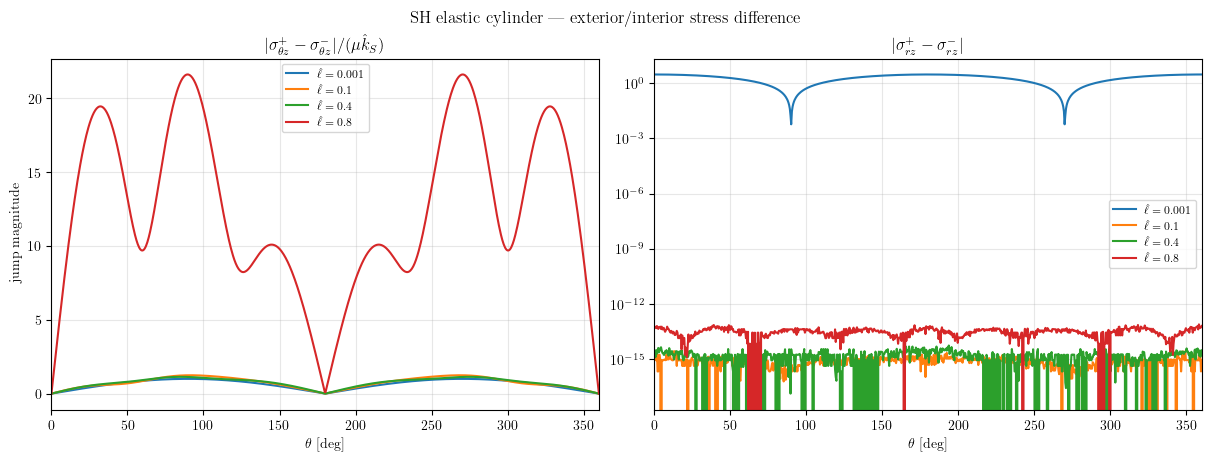

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 2 — EXTERIOR/INTERIOR DIFFERENCE
# ─────────────────────────────────────────────────────────────────────────────

theta = np.linspace(0, 2*np.pi, 800)
theta_deg = np.rad2deg(theta)

khat_val     = 3.0
khat_p_val   = 3.0
lhat_p_val   = 0.1
mu_ratio_val = 2.0
Nmax_bnd     = 200

lhat_vals = [0.001, 0.1, 0.4, 0.8]

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

for lhat_val in lhat_vals:

    sig_tz_ext = boundary_series(sig_tz_ext_func, theta, khat_val, lhat_val,
                                 khat_p_val, lhat_p_val, mu_ratio_val, Nmax_bnd)
    sig_tz_int = boundary_series(sig_tz_int_func, theta, khat_val, lhat_val,
                                 khat_p_val, lhat_p_val, mu_ratio_val, Nmax_bnd)

    sig_rz_ext = boundary_series(sig_rz_ext_func, theta, khat_val, lhat_val,
                                 khat_p_val, lhat_p_val, mu_ratio_val, Nmax_bnd)
    sig_rz_int = boundary_series(sig_rz_int_func, theta, khat_val, lhat_val,
                                 khat_p_val, lhat_p_val, mu_ratio_val, Nmax_bnd)

    axs[0].plot(theta_deg, np.abs(sig_tz_ext - sig_tz_int)/khat_val,
                label=rf"$\hat{{\ell}}={lhat_val}$")

    axs[1].semilogy(theta_deg, np.abs(sig_rz_ext - sig_rz_int),
                    label=rf"$\hat{{\ell}}={lhat_val}$")

axs[0].set_title(r"$|\sigma_{\theta z}^+ - \sigma_{\theta z}^-|/(\mu \hat{k}_S)$")
axs[1].set_title(r"$|\sigma_{rz}^+ - \sigma_{rz}^-|$")

for ax in axs:
    ax.set_xlabel(r"$\theta$ [deg]")
    ax.set_xlim(0, 360)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

axs[0].set_ylabel("jump magnitude")

fig.suptitle("SH elastic cylinder — exterior/interior stress difference")

plt.savefig("figs/SH_E_stress_jump.png", dpi=300)
plt.show()

In [19]:
def incident_boundary_series(func, theta, khat_val, lhat_val,
                             khat_p_val, lhat_p_val, mu_ratio_val,
                             Nmax=200):
    """
    Incident contribution only.
    Exterior field with Bn = Cn = 0.
    """

    total = np.zeros_like(theta, dtype=complex)

    for n_val in range(Nmax + 1):
        term = func(
            n_val, theta,
            khat_val, lhat_val, khat_p_val, lhat_p_val, mu_ratio_val,
            0.0, 0.0, 0.0, 0.0
        )

        term = np.nan_to_num(term, nan=0.0, posinf=0.0, neginf=0.0)
        total += term

    return total


def sigma0_incident(theta, khat_val, lhat_val,
                    khat_p_val, lhat_p_val, mu_ratio_val,
                    Nmax=200):
    """
    sigma_0 = max_theta |sigma_thetaz^incident|.
    """

    sig_inc = incident_boundary_series(
        sig_tz_ext_func,
        theta,
        khat_val, lhat_val,
        khat_p_val, lhat_p_val, mu_ratio_val,
        Nmax
    )

    return np.max(np.abs(sig_inc))

def nice_ticks_integer(rmax):
    rmax_i = int(np.ceil(rmax))
    mid_i = int(np.round(rmax_i / 2))

    if mid_i == 0:
        mid_i = 1

    return [mid_i, rmax_i]

<lambdifygenerated-4>:2: RuntimeWarning: invalid value encountered in scalar multiply
  return (1/8)*n*(-16*1j**n*Dummy_1090**3*Dummy_1092**2*besselj(n + 2, Dummy_1090) + 32*1j**n*Dummy_1090**2*Dummy_1092**2*n*besselj(n + 1, Dummy_1090) - 32*1j**n*Dummy_1090*Dummy_1092**2*n*besselj(n + 2, Dummy_1090) + 16*1j**n*Dummy_1090*Dummy_1092**2*besselj(n + 2, Dummy_1090) + 16*1j**n*Dummy_1090*besselj(n + 2, Dummy_1090) + 64*1j**n*Dummy_1092**2*n**2*besselj(n + 1, Dummy_1090) + 32*1j**n*Dummy_1092**2*n*besselj(n + 1, Dummy_1090) - 32*1j**n*Dummy_1092**2*besselj(n + 1, Dummy_1090) - 32*1j**n*n*besselj(n + 1, Dummy_1090) - 32*1j**n*besselj(n + 1, Dummy_1090) + 8*B_n*Dummy_1090*Dummy_1092**2*n**2*besselk(n, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_1090**2*Dummy_1092**2 + 1) + 1)/Dummy_1092) - 8*B_n*Dummy_1090*Dummy_1092**2*besselk(n, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_1090**2*Dummy_1092**2 + 1) + 1)/Dummy_1092) - 2*B_n*Dummy_1090*Dummy_1092*sqrt(2*sqrt(4*Dummy_1090**2*Dummy_1092**2 + 1) + 2)*besselk(n - 1, (1/

  [singular] n=180
  [singular] n=181
  [singular] n=182
  [singular] n=183
  [singular] n=184
  [singular] n=185
  [singular] n=186


<lambdifygenerated-1>:2: RuntimeWarning: invalid value encountered in scalar subtract
  return [[-besseli(n, (1/2)*sqrt(2)*sqrt(sqrt(4*_Dummy_1030**2*_Dummy_1042**2 + 1) + 1)/_Dummy_1042), besselk(n, (1/2)*sqrt(2)*sqrt(sqrt(4*_Dummy_1041**2*_Dummy_1069**2 + 1) + 1)/_Dummy_1069), hankel1(n, (1/2)*sqrt(2)*sqrt(sqrt(4*_Dummy_1041**2*_Dummy_1069**2 + 1) - 1)/_Dummy_1069), -besselj(n, _Dummy_1030)], [(1/2)*sqrt(2)*sqrt(sqrt(4*_Dummy_1030**2*_Dummy_1042**2 + 1) + 1)*besseli(n - 1, (1/2)*sqrt(2)*sqrt(sqrt(4*_Dummy_1030**2*_Dummy_1042**2 + 1) + 1)/_Dummy_1042)/_Dummy_1042 + (1/2)*sqrt(2)*sqrt(sqrt(4*_Dummy_1030**2*_Dummy_1042**2 + 1) + 1)*besseli(n + 1, (1/2)*sqrt(2)*sqrt(sqrt(4*_Dummy_1030**2*_Dummy_1042**2 + 1) + 1)/_Dummy_1042)/_Dummy_1042, (1/2)*sqrt(2)*sqrt(sqrt(4*_Dummy_1041**2*_Dummy_1069**2 + 1) + 1)*besselk(n - 1, (1/2)*sqrt(2)*sqrt(sqrt(4*_Dummy_1041**2*_Dummy_1069**2 + 1) + 1)/_Dummy_1069)/_Dummy_1069 + (1/2)*sqrt(2)*sqrt(sqrt(4*_Dummy_1041**2*_Dummy_1069**2 + 1) + 1)*besselk(n + 1,

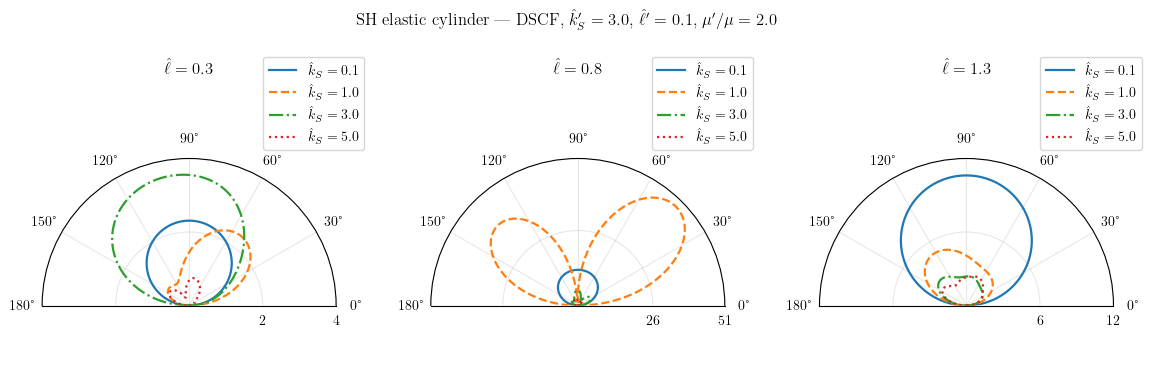

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 3 — DSCF POLAR
# Paper-consistent definition:
# S_d(theta) = |sigma_thetaz^i + sigma_thetaz^s| / sigma_0
# sigma_0 = max_theta |sigma_thetaz^i|
# ─────────────────────────────────────────────────────────────────────────────

theta = np.linspace(0, np.pi, 800)

lhat_vals = [0.3, 0.8, 1.3]
khat_vals = [0.1, 1.0, 3.0, 5.0]

khat_p_val   = 3.0
lhat_p_val   = 0.1
mu_ratio_val = 2.0
Nmax_bnd     = 200

linestyles = ["-", "--", "-.", ":"]

fig, axs = plt.subplots(
    1, 3,
    figsize=(11.5, 4.2),
    subplot_kw={"projection": "polar"},
    constrained_layout=False
)

for ax, lhat_val in zip(axs, lhat_vals):

    for khat_val, ls in zip(khat_vals, linestyles):

        sig_tz_ext = boundary_series(
            sig_tz_ext_func, theta,
            khat_val, lhat_val,
            khat_p_val, lhat_p_val,
            mu_ratio_val,
            Nmax_bnd
        )

        sigma0 = sigma0_incident(
            theta,
            khat_val, lhat_val,
            khat_p_val, lhat_p_val,
            mu_ratio_val,
            Nmax_bnd
        )

        Sd = np.abs(sig_tz_ext) / sigma0

        ax.plot(
            theta, Sd,
            linestyle=ls,
            linewidth=1.6,
            label=rf"$\hat{{k}}_S={khat_val}$"
        )

    rmax = ax.get_rmax()
    rticks = nice_ticks_integer(rmax)
    ax.set_rmax(rticks[-1])
    ax.set_rticks(rticks)
    ax.set_yticklabels([str(t) for t in rticks])

    ax.set_title(rf"$\hat{{\ell}}={lhat_val}$", pad=8)
    ax.set_thetamin(0)
    ax.set_thetamax(180)
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)
    ax.grid(True, alpha=0.3)

    ax.legend(
        fontsize=10,
        loc="upper right",
        bbox_to_anchor=(1.12, 1.12),
        frameon=True
    )

fig.suptitle(
    rf"SH elastic cylinder — DSCF, "
    rf"$\hat{{k}}_S'={khat_p_val}$, "
    rf"$\hat{{\ell}}'={lhat_p_val}$, "
    rf"$\mu'/\mu={mu_ratio_val}$",
    y=0.96
)

fig.subplots_adjust(
    left=0.04,
    right=0.98,
    bottom=0.08,
    top=0.78,
    wspace=0.28
)
plt.savefig(
    "figs/SH_E_DSCF_polar_paper_definition.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15
)
plt.show()